# Proyecto K-Means

In [179]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from mpl_toolkits.mplot3d import Axes3D

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from sklearn.model_selection import train_test_split

from xgboost import XGBClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay
)

In [121]:
url = "https://breathecode.herokuapp.com/asset/internal-link?id=809&path=housing.csv"
data = pd.read_csv(url)

data.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [122]:
data = data[["Latitude", "Longitude", "MedInc"]]

data.head()

,Latitude,Longitude,MedInc
0,37.88,-122.23,8.3252
1,37.86,-122.22,8.3014
2,37.85,-122.24,7.2574
3,37.85,-122.25,5.6431
4,37.85,-122.25,3.8462


In [123]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Latitude   20640 non-null  float64
 1   Longitude  20640 non-null  float64
 2   MedInc     20640 non-null  float64
dtypes: float64(3)
memory usage: 483.9 KB


In [124]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Latitude,20640.0,35.631861,2.135952,32.5400,33.9300,34.2600,37.71000,41.9500
Longitude,20640.0,-119.569704,2.003532,-124.3500,-121.8000,-118.4900,-118.01000,-114.3100
MedInc,20640.0,3.870671,1.899822,0.4999,2.5634,3.5348,4.74325,15.0001


### Distribución de los datos

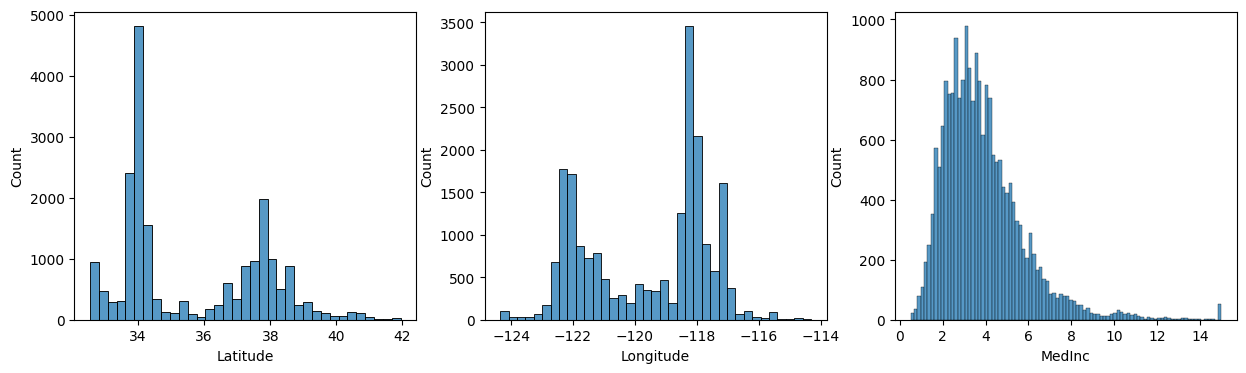

In [125]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))

sns.histplot(data["Latitude"], ax=axes[0])
sns.histplot(data["Longitude"], ax=axes[1])
sns.histplot(data["MedInc"], ax=axes[2])

plt.show()

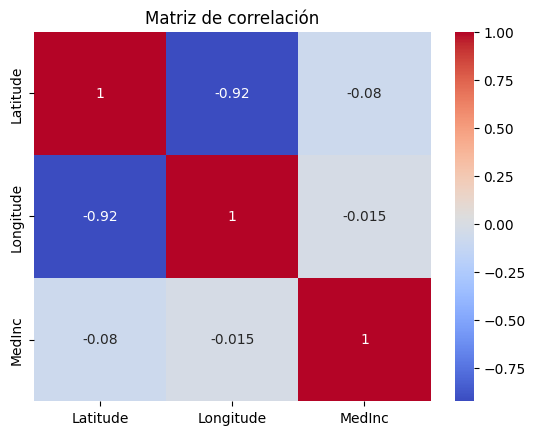

In [126]:
sns.heatmap(data.corr(), annot=True, cmap="coolwarm")
plt.title("Matriz de correlación")
plt.show()

## Aplicamos el Split y Scaler

In [127]:
train, test = train_test_split(data, test_size=0.2, random_state=42)

scaler = StandardScaler()

X_train = scaler.fit_transform(train)
X_test = scaler.transform(test)

## Aplicamos método para elegir el mejor "k"

### Método Elbow

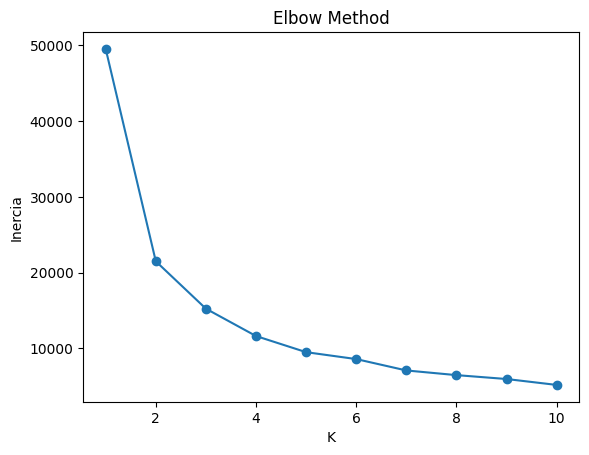

In [128]:
inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_train)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 11), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("K")
plt.ylabel("Inercia")
plt.show()

### Método Silhouette

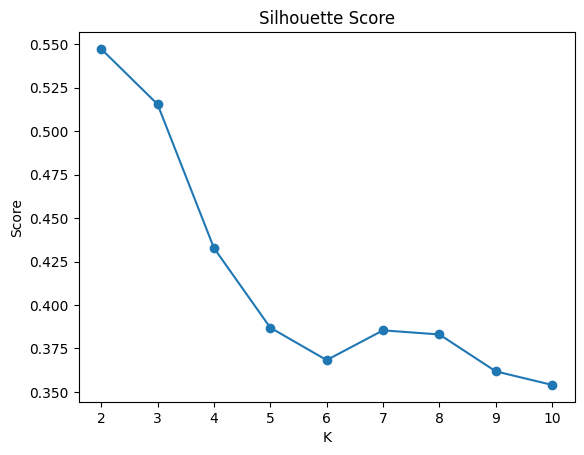

In [129]:
scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_train)
    scores.append(silhouette_score(X_train, labels))

plt.plot(range(2, 11), scores, marker='o')
plt.title("Silhouette Score")
plt.xlabel("K")
plt.ylabel("Score")
plt.show()

El análisis mediante el método del codo y el coeficiente de silhouette sugiere un número óptimo de clusters entre 2 y 4. Sin embargo, se utilizarán 6 clusters para cumplir con los requerimientos del ejercicio.

# Paso 2: Aplicamos K-means y generamos variable "cluster"

In [130]:
kmeans = KMeans(n_clusters=6, random_state=42)

train["cluster"] = kmeans.fit_predict(X_train)
test["cluster"] = kmeans.predict(X_test)

## Vemos la distribución de los datos

In [131]:
train

,Latitude,Longitude,MedInc,cluster
14196,32.71,-117.03,3.2596,3
8267,33.77,-118.16,3.8125,3
17445,34.66,-120.48,4.1563,1
14265,32.69,-117.11,1.9425,3
2271,36.78,-119.80,3.5542,5
...,...,...,...,...
11284,33.78,-117.96,6.3700,1
11964,34.02,-117.43,3.0500,3
5390,34.03,-118.38,2.9344,3
860,37.58,-121.96,5.7192,0


In [132]:
test

,Latitude,Longitude,MedInc,cluster
20046,36.06,-119.01,1.6812,3
3024,35.14,-119.46,2.5313,3
15663,37.80,-122.44,3.4801,5
20484,34.28,-118.72,5.7376,1
9814,36.62,-121.93,3.7250,5
...,...,...,...,...
15362,33.36,-117.22,4.6050,1
16623,35.36,-120.83,2.7266,5
18086,37.31,-122.05,9.2298,2
2144,36.77,-119.76,2.7850,5


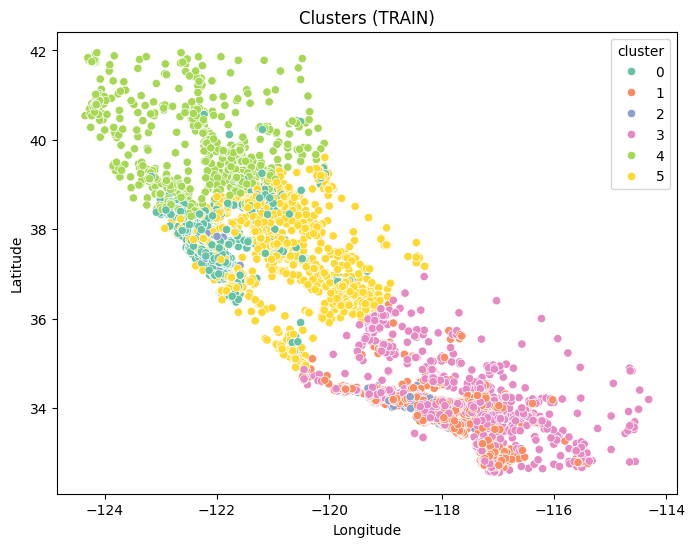

In [133]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=train["Longitude"],
    y=train["Latitude"],
    hue=train["cluster"],
    palette="Set2"
)

plt.title("Clusters (TRAIN)")
plt.show()

In [134]:
fig = px.scatter_3d(
    train,
    x="Longitude",
    y="Latitude",
    z="MedInc",
    color="cluster",
    title="Clusters de viviendas (3D interactivo)"
)

fig.show()

Los clusters muestran agrupaciones geográficas claras, donde se observan zonas diferenciadas en función de la ubicación (latitud y longitud) y el nivel de ingreso medio. Algunas regiones presentan ingresos más altos, mientras que otras concentran valores más bajos.

# Paso 3: Comparamos la data de "Train" con la de "Test"

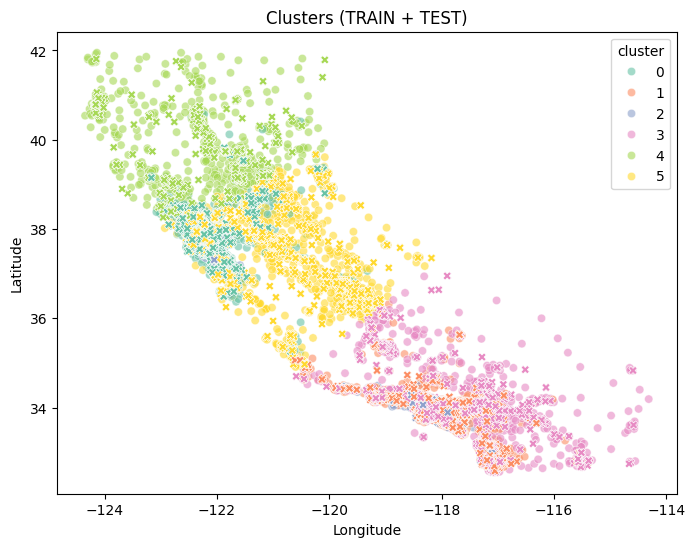

In [135]:
plt.figure(figsize=(8,6))

# TRAIN
sns.scatterplot(
    x=train["Longitude"],
    y=train["Latitude"],
    hue=train["cluster"],
    palette="Set2",
    alpha=0.6
)

# TEST
sns.scatterplot(
    x=test["Longitude"],
    y=test["Latitude"],
    hue=test["cluster"],
    palette="Set2",
    marker="X",
    legend=False
)

plt.title("Clusters (TRAIN + TEST)")
plt.show()

Esto indica que el modelo K-Means logra generalizar adecuadamente, al incorporar los datos del conjunto de prueba en la visualización se observa que estos se asignan coherentemente a los clusters definidos en el conjunto de entrenamiento.

### Analizamos ubicación de centroides

In [136]:
# centroides en escala escalada
centroids_scaled = kmeans.cluster_centers_

# volver a escala original
centroids = scaler.inverse_transform(centroids_scaled)

centroids_df = pd.DataFrame(centroids, columns=["Latitude", "Longitude", "MedInc"])
centroids_df["cluster"] = range(6)

centroids_df

,Latitude,Longitude,MedInc,cluster
0,37.737705,-121.960844,5.369962,0
1,33.872832,-118.028775,5.222613,1
2,34.883492,-119.216570,10.300009,2
3,33.926216,-117.925564,2.719283,3
4,39.638523,-122.396157,2.412564,4
5,37.557821,-121.262268,2.812405,5


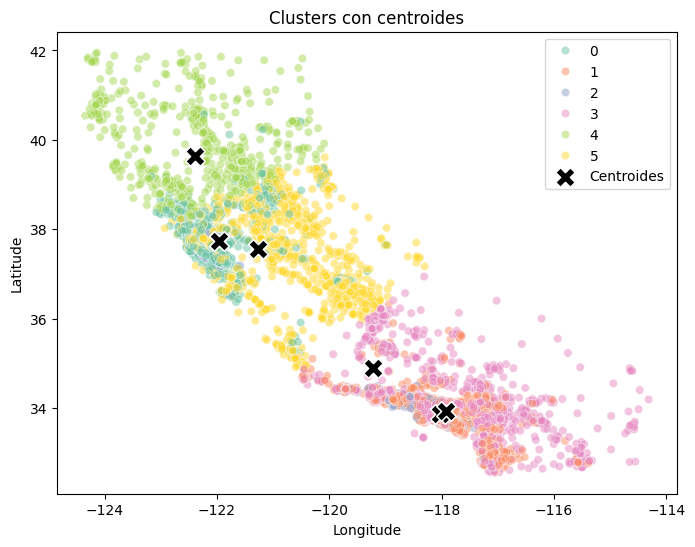

In [137]:
plt.figure(figsize=(8,6))

# puntos train
sns.scatterplot(
    x=train["Longitude"],
    y=train["Latitude"],
    hue=train["cluster"],
    palette="Set2",
    alpha=0.5
)

# centroides
sns.scatterplot(
    x=centroids_df["Longitude"],
    y=centroids_df["Latitude"],
    color="black",
    s=200,
    marker="X",
    label="Centroides"
)

plt.title("Clusters con centroides")
plt.legend()
plt.show()

In [148]:
train.groupby("cluster")["MedInc"].mean().sort_values()

cluster
4     2.406233
3     2.720662
5     2.816021
1     5.225473
0     5.370513
2    10.305096
Name: MedInc, dtype: float64

Vemos que hay una clara segmentación de clases, por lo que reagruparemos en 3 clases (baja, media, alta)

In [149]:
low = [4, 3, 5]
mid = [1, 0]
high = [2]

def income_level(cluster):
    if cluster in low:
        return 0  # Baja
    elif cluster in mid:
        return 1  # Media
    else:
        return 2  # Alta

train["income_level"] = train["cluster"].apply(income_level)
test["income_level"] = test["cluster"].apply(income_level)

In [153]:
train["income_level"].value_counts()

income_level
0    10001
1     6028
2      483
Name: count, dtype: int64

In [154]:
features = ["Latitude", "Longitude", "MedInc"]

X_train_sup = train[features]
y_train_sup = train["income_level"]

X_test_sup = test[features]
y_test_sup = test["income_level"]

# Paso 4: Generamos modelo de Xgboost y evaluamos

In [155]:
model = XGBClassifier(random_state=42)
model.fit(X_train_sup, y_train_sup)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [156]:
y_pred = model.predict(X_test_sup)
y_proba = model.predict_proba(X_test_sup)

### Evaluamos resultados

In [157]:
roc_auc = roc_auc_score(y_test_sup, y_proba, multi_class="ovr")

print("ROC AUC:", roc_auc)
print(classification_report(y_test_sup, y_pred))

ROC AUC: 0.9999667184832357
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2558
           1       0.99      1.00      0.99      1454
           2       0.99      0.96      0.97       116

    accuracy                           1.00      4128
   macro avg       0.99      0.98      0.99      4128
weighted avg       1.00      1.00      1.00      4128



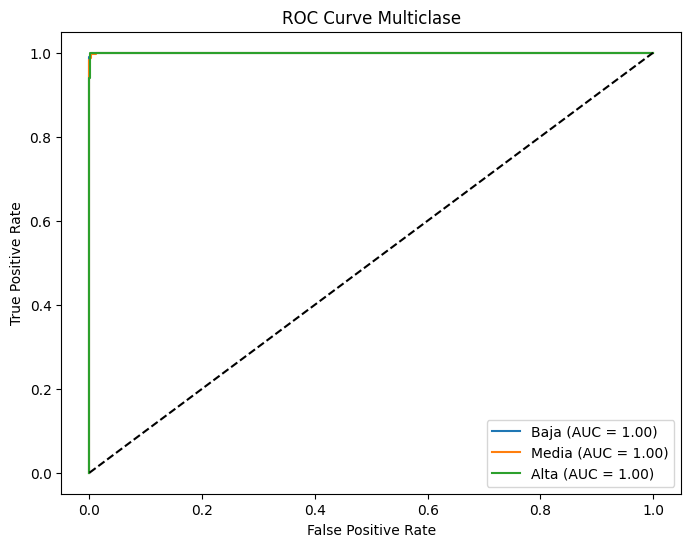

In [175]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# clases: 0=bajo, 1=medio, 2=alto
y_test_bin = label_binarize(y_test_sup, classes=[0,1,2])

plt.figure(figsize=(8,6))

class_names = ["Baja", "Media", "Alta"]

for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{class_names[i]} (AUC = {roc_auc:.2f})")

plt.plot([0,1], [0,1], 'k--')  # línea base
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Multiclase")
plt.legend()
plt.show()

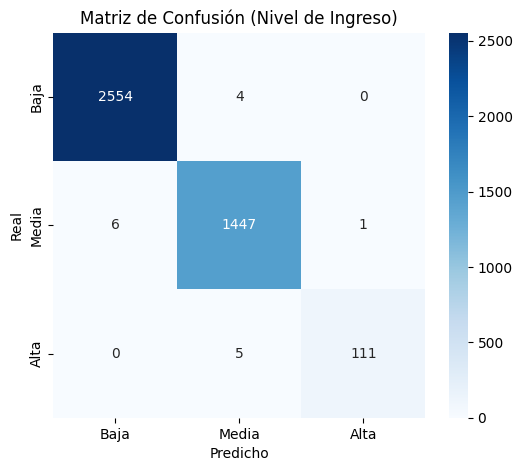

In [ ]:
cm = confusion_matrix(y_test_sup, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión (Nivel de Ingreso)")
plt.show()

In [170]:
from sklearn.model_selection import cross_val_score

model_prueba = XGBClassifier(random_state=42)

scores = cross_val_score(
    model_prueba,
    X_train_sup,
    y_train_sup,
    cv=5,
    scoring="accuracy"
)

print("Accuracy CV:", scores)
print("Promedio:", scores.mean())

Accuracy CV: [0.99485316 0.9939449  0.99606299 0.99273168 0.99394306]
Promedio: 0.9943071594147567


In [171]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test_sup)

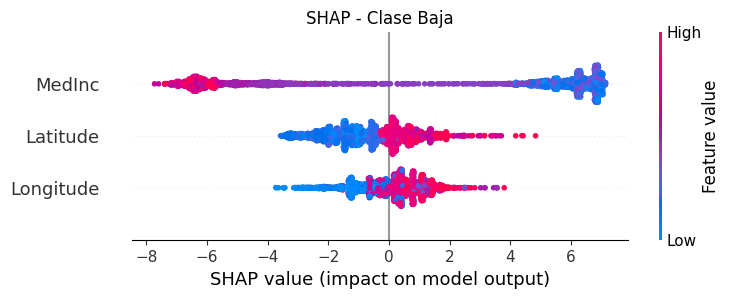

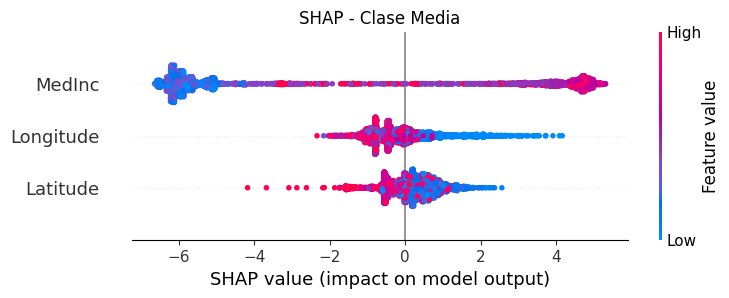

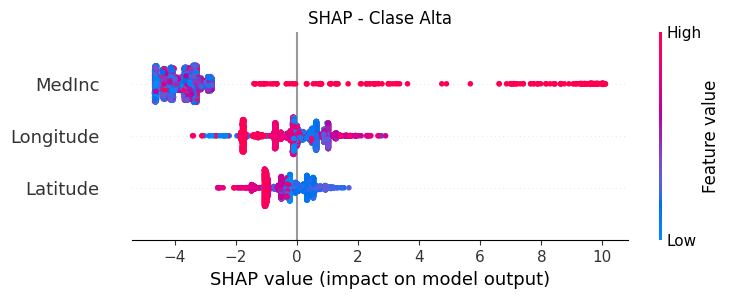

In [177]:
for i in range(3):
    plt.title(f"SHAP - Clase {class_names[i]}")
    shap.plots.beeswarm(shap_values[:,:,i])

# Conclusión:

- En este proyecto usamos K-Means para agrupar las viviendas según su ubicación y nivel de ingreso, lo que permitió identificar distintos grupos dentro del territorio. Luego simplificamos estos grupos en tres niveles: bajo, medio y alto, para que fuera más fácil interpretarlos.
- Con esa nueva clasificación entrenamos un modelo XGBoost, que logró predecir bastante bien a qué grupo pertenece cada vivienda. Además, con SHAP vimos que el ingreso (MedInc) es la variable más importante.

# Guardado de modelos

In [181]:
import joblib

# Modelo Scaler
joblib.dump(scaler, "../models/scaler.pkl")

# Modelo KMeans
joblib.dump(kmeans, "../models/kmeans_model.pkl")

# Modelo XGBoost
joblib.dump(model, "../models/xgboost_model.pkl")

['../models/xgboost_model.pkl']